<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B08%5D%20-%20NLP/nlp_nltk_sms_spam_publico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP aplicado a negocio con NLTK y un dataset público  
## Detección de SMS spam con procesamiento clásico de texto

Este notebook sirve como **introducción completa y práctica al flujo de trabajo típico en NLP clásico usando NLTK** sobre un dataset **real y público** de mensajes SMS etiquetados como *spam* o *ham*.

La idea no es solo entrenar un modelo, sino recorrer el flujo completo:

1. Cargar un dataset real disponible online.
2. Entender qué problema de negocio estamos resolviendo.
3. Explorar los datos.
4. Limpiar y normalizar texto con **NLTK**.
5. Construir variables útiles para un clasificador de texto.
6. Entrenar un modelo base de clasificación.
7. Evaluar resultados y revisar errores.
8. Traducir lo técnico a decisiones de negocio.

Este tipo de problema aparece en muchos contextos reales:

- filtrado de spam,
- detección de fraude textual,
- clasificación de incidencias,
- priorización automática de mensajes,
- moderación de contenido,
- y automatización de soporte.

## 1. Objetivos del notebook

Al finalizar este notebook deberías tener una visión bastante completa de:

- cómo se estructura un problema de NLP en clasificación binaria de texto,
- qué aporta **NLTK** dentro del pipeline,
- cómo tokenizar, filtrar stopwords y lematizar,
- por qué conviene normalizar texto antes de modelar,
- cómo representar texto con **TF-IDF**,
- cómo evaluar un clasificador de spam,
- cómo interpretar errores y riesgos de negocio,
- y cómo convertir esto en una micro-solución usable.

## 2. Dataset público que vamos a utilizar

Usaremos el dataset **SMS Spam Collection**, uno de los clásicos para introducir NLP aplicado a clasificación de mensajes.

Cada registro contiene:

- una etiqueta: `ham` o `spam`
- el texto del mensaje

Esto lo convierte en un ejemplo muy bueno de negocio para:

- filtros automáticos en email/SMS,
- priorización de bandejas de entrada,
- protección frente a campañas masivas,
- y automatización de clasificación textual.

A nivel didáctico, además, tiene varias ventajas:

- el problema se entiende rápido,
- las etiquetas son claras,
- el dataset es razonablemente pequeño,
- y permite centrarnos en el flujo de NLP.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression


def ensure_nltk_resource(resource_path: str, download_name: str):
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name)


ensure_nltk_resource("tokenizers/punkt", "punkt")
ensure_nltk_resource("corpora/stopwords", "stopwords")
ensure_nltk_resource("corpora/wordnet", "wordnet")
ensure_nltk_resource("corpora/omw-1.4", "omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 3. Carga de datos

Vamos a descargar el dataset desde una fuente pública online.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(DATA_URL, sep="	", header=None, names=["label", "message"])
print("Shape:", df.shape)
df.head()

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 4. Primera inspección del dataset

Antes de modelar, toca mirar qué tenemos entre manos.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
df.columns.tolist()

['label', 'message']

Nos vamos a quedar con un conjunto simple y útil de variables para este ejercicio:

- `message`: contenido del SMS
- `label`: etiqueta objetivo (`ham` o `spam`)

## 5. Revisión básica de calidad de datos

In [6]:
df.isna().sum()

,0
message,0
label,0


In [7]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


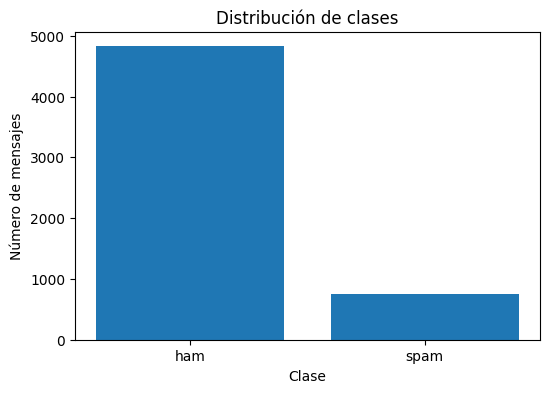

In [8]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de mensajes")
plt.show()

### Lectura rápida de negocio

Aquí suele aparecer el primer detalle importante: **el dataset está desbalanceado**.

Eso significa que si una clase domina claramente, un modelo muy simple podría acertar bastante solo con predecir siempre la clase mayoritaria. Por eso luego compararemos contra un baseline tonto.

## 6. Exploración de ejemplos reales

In [9]:
pd.set_option("display.max_colwidth", 300)
df.sample(10, random_state=42)

,message,label
3245,Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u:,ham
944,And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed,ham
1044,Mmm thats better now i got a roast down me! id b better if i had a few drinks down me 2! Good indian?,ham
2484,Mm have some kanji dont eat anything heavy ok,ham
812,So there's a ring that comes with the guys costumes. It's there so they can gift their future yowifes. Hint hint,ham
2973,Sary just need Tim in the bollox &it hurt him a lot so he tol me!,ham
2991,"Love isn't a decision, it's a feeling. If we could decide who to love, then, life would be much simpler, but then less magical",ham
2942,My supervisor find 4 me one lor i thk his students. I havent ask her yet. Tell u aft i ask her.,ham
230,Dear good morning now only i am up,ham
1181,I'm in chennai velachery:),ham


In [11]:
for label in ["ham", "spam"]:
    print(f"--- Ejemplos de la clase: {label} ---")
    display(df[df["label"] == label][["message"]].sample(5, random_state=7))

--- Ejemplos de la clase: ham ---


,message
5521,You are a big chic. Common. Declare
902,How is it possible to teach you. And where.
931,I'm really sorry i won't b able 2 do this friday.hope u can find an alternative.hope yr term's going ok:-)
5351,Yup it's at paragon... I havent decided whether 2 cut yet... Hee...
3590,I've sent my wife your text. After we buy them she'll tell you what to do. So just relax. We should go get them this wkend.


--- Ejemplos de la clase: spam ---


,message
1699,"Free msg. Sorry, a service you ordered from 81303 could not be delivered as you do not have sufficient credit. Please top up to receive the service."
2664,8007 FREE for 1st week! No1 Nokia tone 4 ur mob every week just txt NOKIA to 8007 Get txting and tell ur mates www.getzed.co.uk POBox 36504 W4 5WQ norm 150p/tone 16+
1536,You have won a Nokia 7250i. This is what you get when you win our FREE auction. To take part send Nokia to 86021 now. HG/Suite342/2Lands Row/W1JHL 16+
5237,Someonone you know is trying to contact you via our dating service! To find out who it could be call from your mobile or landline 09064015307 BOX334SK38ch
3856,Free msg: Single? Find a partner in your area! 1000s of real people are waiting to chat now!Send CHAT to 62220Cncl send STOPCS 08717890890£1.50 per msg


## 7. Longitud de los textos

In [12]:
df["text_len"] = df["message"].str.len()
df["word_count"] = df["message"].str.split().str.len()

df[["message", "label", "text_len", "word_count"]].head()

,message,label,text_len,word_count
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",ham,111,20
1,Ok lar... Joking wif u oni...,ham,29,6
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,spam,155,28
3,U dun say so early hor... U c already then say...,ham,49,11
4,"Nah I don't think he goes to usf, he lives around here though",ham,61,13


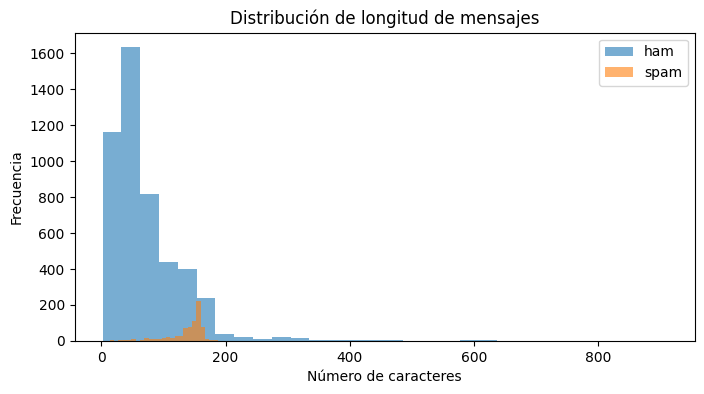

In [13]:
plt.figure(figsize=(8, 4))
for label in ["ham", "spam"]:
    subset = df[df["label"] == label]
    plt.hist(subset["text_len"], bins=30, alpha=0.6, label=label)

plt.title("Distribución de longitud de mensajes")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [14]:
df.groupby("label")[["text_len", "word_count"]].mean().round(2)

,text_len,word_count
label,,
ham,71.48,14.31
spam,138.67,23.91


Esto ya da pistas interesantes: en muchos datasets de spam, los mensajes promocionales o de phishing suelen ser **más largos**, más formulaicos y con más llamadas a la acción.

No siempre, claro. Los spammers también aprenden. Son bastante pesados y, además, iterativos.

## 8. Preparación del texto con NLTK

In [15]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def nltk_preprocess(text: str):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)
    tokens = [tok for tok in tokens if tok.isalpha()]
    tokens = [tok for tok in tokens if tok not in stop_words]
    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]

    return lemmas


def preprocess_to_text(text: str) -> str:
    return " ".join(nltk_preprocess(text))

### ¿Qué estamos haciendo exactamente con NLTK?

En esta parte aplicamos varias operaciones clásicas de NLP:

- **lowercasing**: pasar todo a minúsculas,
- **tokenización**: dividir el texto en palabras,
- **eliminación de ruido**: URLs, números y puntuación,
- **stopwords**: quitar palabras muy frecuentes que suelen aportar poco,
- **lematización**: reducir palabras a una forma más canónica.

In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
df["tokens_nltk"] = df["message"].apply(nltk_preprocess)
df["clean_text"] = df["message"].apply(preprocess_to_text)

df[["message", "tokens_nltk", "clean_text"]].head()

,message,tokens_nltk,clean_text
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...","[go, jurong, point, crazy, available, bugis, n, great, world, la, e, buffet, cine, got, amore, wat]",go jurong point crazy available bugis n great world la e buffet cine got amore wat
1,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]",ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,"[free, entry, wkly, comp, win, fa, cup, final, tkts, st, may, text, fa, receive, entry, questionstd, txt, ratetcs, apply]",free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply
3,U dun say so early hor... U c already then say...,"[u, dun, say, early, hor, u, c, already, say]",u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives around here though","[nah, dont, think, go, usf, life, around, though]",nah dont think go usf life around though


### Comparativa rápida antes / después

In [20]:
for original, cleaned in df[["message", "clean_text"]].sample(5, random_state=7).values:
    print("ORIGINAL:")
    print(original)
    print("LIMPIO:")
    print(cleaned)
    print("-" * 80)

ORIGINAL:
You will be in the place of that man
LIMPIO:
place man
--------------------------------------------------------------------------------
ORIGINAL:
What's your room number again? Wanna make sure I'm knocking on the right door
LIMPIO:
whats room number wan na make sure im knocking right door
--------------------------------------------------------------------------------
ORIGINAL:
R ü going 4 today's meeting?
LIMPIO:
r ü going today meeting
--------------------------------------------------------------------------------
ORIGINAL:
Too late. I said i have the website. I didn't i have or dont have the slippers
LIMPIO:
late said website didnt dont slipper
--------------------------------------------------------------------------------
ORIGINAL:
Stop knowing me so well!
LIMPIO:
stop knowing well
--------------------------------------------------------------------------------


## 9. Exploración léxica con NLTK

In [22]:
ham_tokens = [tok for row in df[df["label"] == "ham"]["tokens_nltk"] for tok in row]
spam_tokens = [tok for row in df[df["label"] == "spam"]["tokens_nltk"] for tok in row]

ham_fdist = FreqDist(ham_tokens)
spam_fdist = FreqDist(spam_tokens)

print("Top 15 tokens más frecuentes en ham:")
print(ham_fdist.most_common(15))

print("Top 15 tokens más frecuentes en spam:")
print(spam_fdist.most_common(15))

Top 15 tokens más frecuentes en ham:
[('u', 1057), ('im', 453), ('get', 320), ('go', 279), ('ltgt', 276), ('ok', 273), ('dont', 266), ('ur', 246), ('come', 246), ('got', 245), ('call', 243), ('know', 241), ('ill', 238), ('like', 234), ('good', 225)]
Top 15 tokens más frecuentes en spam:
[('call', 375), ('free', 221), ('u', 168), ('txt', 152), ('ur', 144), ('text', 138), ('mobile', 137), ('stop', 120), ('claim', 115), ('reply', 103), ('prize', 95), ('p', 92), ('get', 83), ('tone', 77), ('service', 72)]


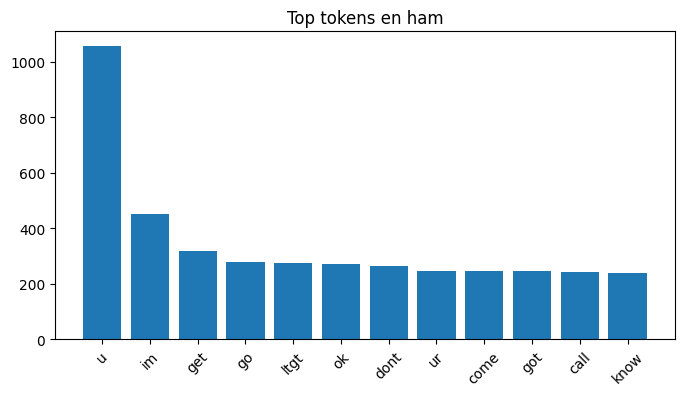

In [23]:
ham_top = pd.DataFrame(ham_fdist.most_common(12), columns=["token", "freq"])
spam_top = pd.DataFrame(spam_fdist.most_common(12), columns=["token", "freq"])

plt.figure(figsize=(8, 4))
plt.bar(ham_top["token"], ham_top["freq"])
plt.title("Top tokens en ham")
plt.xticks(rotation=45)
plt.show()

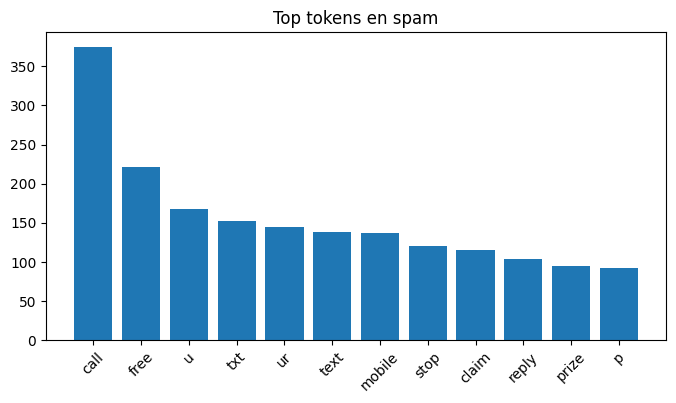

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(spam_top["token"], spam_top["freq"])
plt.title("Top tokens en spam")
plt.xticks(rotation=45)
plt.show()

### Lectura rápida de negocio

Aquí suelen aparecer tokens tipo `free`, `claim`, `txt`, `stop`, `mobile`, `reply`, `prize`, etc.

Eso ya empieza a contar una historia: el spam suele apoyarse en:

- urgencia,
- incentivos,
- lenguaje promocional,
- y acciones concretas que buscan respuesta inmediata.

Este tipo de análisis es simple, pero útil para entender el problema antes de enchufar un modelo. Primero mirar, luego modelar. No al revés.

## 10. Definición del problema de ML

In [25]:
X = df["clean_text"]
y = df["label"]

X.shape, y.shape

((5572,), (5572,))

## 11. Train / test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4457,)
Test: (1115,)


## 12. Baseline tonto pero obligatorio

In [27]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("Accuracy baseline:", round(accuracy_score(y_test, dummy_pred), 4))
print("F1 macro baseline:", round(f1_score(y_test, dummy_pred, average="macro"), 4))

Accuracy baseline: 0.8664
F1 macro baseline: 0.4642


Este baseline sirve para responder una pregunta muy sana:

> ¿Nuestro modelo aprende algo real o simplemente gana por inercia del dataset?

Pregunta básica. Pregunta necesaria.

## 13. Pipeline principal: TF-IDF + Logistic Regression

In [28]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

logreg_pipeline.fit(X_train, y_train)
logreg_pred = logreg_pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, logreg_pred), 4))
print("F1 macro:", round(f1_score(y_test, logreg_pred, average="macro"), 4))
print()
print(classification_report(y_test, logreg_pred))

Accuracy: 0.9767
F1 macro: 0.9499

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.91      0.92      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [29]:
# Extraer vectorizador ya entrenado
vectorizer = logreg_pipeline.named_steps["tfidf"]

print("Número de features TF-IDF:", len(vectorizer.get_feature_names_out()))
print("Primeras 30 features:")
print(vectorizer.get_feature_names_out()[:30])

Número de features TF-IDF: 5000
Primeras 30 features:
['aah' 'abiola' 'abj' 'able' 'able come' 'able deliver' 'abt'
 'abt already' 'abt tht' 'abta' 'abta complimentary' 'aburo' 'aburo enjoy'
 'ac' 'acc' 'accept' 'accept brother' 'accept dayu' 'access' 'accident'
 'accidentally' 'account' 'account statement' 'ache' 'across' 'across sea'
 'action' 'activate' 'activity' 'actually']


## 14. Matriz de confusión del modelo

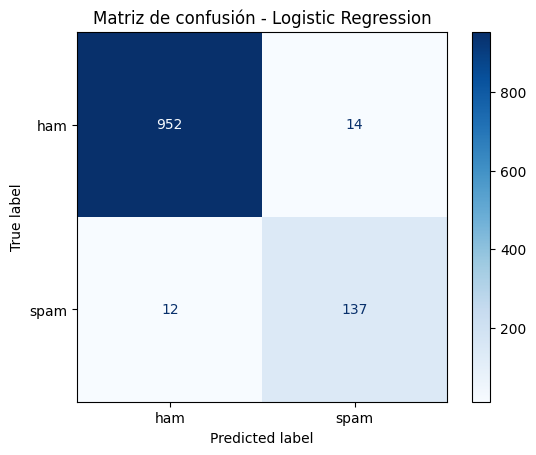

In [30]:
cm = confusion_matrix(y_test, logreg_pred, labels=logreg_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_pipeline.classes_)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Logistic Regression")
plt.show()

## 15. Comparativa rápida: texto bruto vs texto preprocesado

In [31]:
X_raw = df["message"]
y_raw = df["label"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

raw_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

raw_pipeline.fit(X_train_raw, y_train_raw)
raw_pred = raw_pipeline.predict(X_test_raw)

results = pd.DataFrame({
    "modelo": ["Baseline", "Texto bruto", "Texto con NLTK"],
    "accuracy": [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test_raw, raw_pred),
        accuracy_score(y_test, logreg_pred)
    ],
    "f1_macro": [
        f1_score(y_test, dummy_pred, average="macro"),
        f1_score(y_test_raw, raw_pred, average="macro"),
        f1_score(y_test, logreg_pred, average="macro")
    ]
})

results.sort_values("f1_macro", ascending=False)

,modelo,accuracy,f1_macro
1,Texto bruto,0.980269,0.957150
2,Texto con NLTK,0.976682,0.949931
0,Baseline,0.866368,0.464200


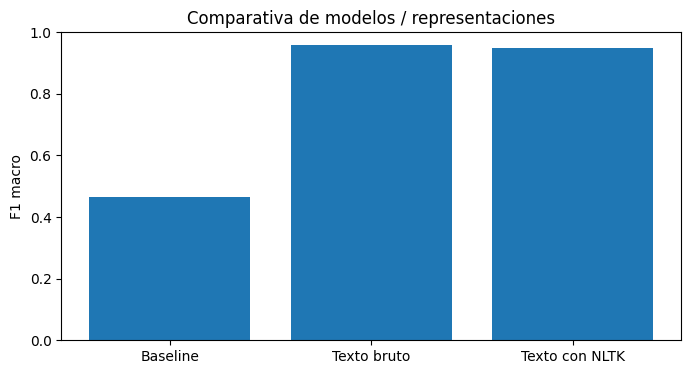

In [32]:
plt.figure(figsize=(8, 4))
plt.bar(results["modelo"], results["f1_macro"])
plt.title("Comparativa de modelos / representaciones")
plt.ylabel("F1 macro")
plt.ylim(0, 1)
plt.show()

### Conclusión intermedia

No siempre el preprocesado agresivo mejora muchísimo el resultado. A veces ayuda bastante; otras veces, solo un poco. En este caso lo empeora porque perdemos señales como !!! o Free!!! que sí tienen poder predictor.

Generalmente, aunque la mejora sea modesta, **sí suele mejorar la interpretabilidad, la limpieza del vocabulario y la consistencia del pipeline**.

## 16. Interpretabilidad: palabras más influyentes

In [33]:
tfidf = logreg_pipeline.named_steps["tfidf"]
model = logreg_pipeline.named_steps["model"]
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "token": feature_names,
    "coef": coefficients
})

spam_top = coef_df.sort_values("coef", ascending=False).head(15)
ham_top = coef_df.sort_values("coef", ascending=True).head(15)

print("Tokens más asociados a spam:")
display(spam_top)

print("Tokens más asociados a ham:")
display(ham_top)

Tokens más asociados a spam:


,token,coef
4553,txt,5.188398
1058,free,4.390788
2756,mobile,3.908382
520,claim,3.902064
364,call,3.806208
4376,text,3.670022
4236,stop,3.588731
3859,reply,3.548681
3619,prize,3.201404
4015,service,2.934796


Tokens más asociados a ham:


,token,coef
2427,ltgt,-2.409759
3166,ok,-2.136429
1712,ill,-2.091354
1746,im,-2.083946
1587,home,-1.633374
1285,got,-1.559669
2131,later,-1.532589
1517,hey,-1.518813
4151,sorry,-1.458668
688,da,-1.418494


### Lectura de negocio

Este análisis permite responder preguntas muy útiles:

- ¿qué lenguaje suele activar el modelo como spam?
- ¿qué patrones son más típicos de mensajes legítimos?
- ¿hay señales sospechosas demasiado obvias?
- ¿hay tokens que podrían inducir falsos positivos?

Esto no sustituye una revisión de calidad, pero sí ayuda mucho a explicar el comportamiento del modelo a perfiles de negocio o compliance.

## 17. Análisis de errores

In [34]:
error_df = pd.DataFrame({
    "message": X_test,
    "real": y_test,
    "pred": logreg_pred
}).reset_index(drop=True)

errors = error_df[error_df["real"] != error_df["pred"]].copy()
print("Número de errores:", errors.shape[0])
errors.head(15)

Número de errores: 26


,message,real,pred
27,alright new goal,ham,spam
44,freemsg hey darling week word back id like fun still tb ok xxx std chgs send rcv,spam,ham
78,u receive msg,ham,spam
179,pete please ring meive hardly gotany credit,ham,spam
196,ringtoneking,spam,ham
197,please charge mobile get morning,ham,spam
219,sorry missed call let talk time im,spam,ham
235,latest news police station toilet stolen cop nothing go,spam,ham
302,hitechnical supportproviding assistance u customer call email,ham,spam
345,sir goodmorning free call,ham,spam


### Busca patrones como estos:

- mensajes legítimos con lenguaje promocional,
- spam corto que parece inocente,
- abreviaturas raras,
- ruido textual,
- mensajes ambiguos que incluso un humano dudaría cómo etiquetar.

Y esto es importante: **no todos los errores valen lo mismo**.

En spam detection suele ser peor marcar como legítimo un spam peligroso que marcar como spam un mensaje dudoso. Depende del caso de uso, pero el coste del error importa más que el numerito bonito del accuracy.

## 18. Predicciones sobre mensajes nuevos

In [35]:
examples = [
    "Congratulations! You have won a free holiday. Reply WIN now.",
    "Can you send me the meeting notes before 5 pm?",
    "URGENT! Claim your prize by texting YES to 80085",
    "I will be 10 minutes late, see you soon"
]

examples_clean = [preprocess_to_text(x) for x in examples]
preds = logreg_pipeline.predict(examples_clean)

pd.DataFrame({
    "message": examples,
    "clean_text": examples_clean,
    "prediction": preds
})

,message,clean_text,prediction
0,Congratulations! You have won a free holiday. Reply WIN now.,congratulation free holiday reply win,spam
1,Can you send me the meeting notes before 5 pm?,send meeting note pm,ham
2,URGENT! Claim your prize by texting YES to 80085,urgent claim prize texting yes,spam
3,"I will be 10 minutes late, see you soon",minute late see soon,ham


### Posible uso en negocio

Un sistema así podría integrarse en un flujo sencillo:

1. entra un mensaje,
2. se preprocesa,
3. el modelo estima si es spam o no,
4. si la confianza es alta, se clasifica automáticamente,
5. si la confianza es dudosa, pasa a revisión humana.

Podemos aplicar **HITL** y automatización razonable.

## 19. Limitaciones del enfoque clásico

Aunque este enfoque funciona sorprendentemente bien, tiene límites claros:

- no entiende el contexto como un LLM moderno,
- sufre con ironía, ambigüedad y mensajes muy creativos,
- depende bastante de ejemplos históricos,
- requiere mantener pipeline y vocabulario,
- y puede degradarse si cambian los patrones de spam.

Aun así, para muchos casos reales sigue siendo una solución excelente por:

- bajo coste,
- rapidez,
- interpretabilidad,
- y facilidad de despliegue.

## Conclusiones finales

En este notebook hemos recorrido un flujo bastante completo de NLP clásico con NLTK:

- cargamos un dataset público online,
- entendimos el problema de negocio,
- exploramos ejemplos y distribución,
- aplicamos tokenización, stopwords y lematización con NLTK,
- representamos el texto con TF-IDF,
- entrenamos un clasificador,
- evaluamos resultados,
- e inspeccionamos errores e interpretabilidad.

La idea clave no es memorizar funciones. Es entender el flujo:

> **texto bruto → limpieza inteligente → representación numérica → modelo → evaluación → decisión de negocio**

Ese patrón aparece una y otra vez en NLP aplicado.
